# Day 8 — Predictive Modeling & Evaluation

**Caspian Maritime Delay-Risk Forecasting** — leakage-corrected version.

## What changed in this version

The original Day 8 had **target leakage**. `is_risk_day` is defined by
threshold rules on same-day wind, gusts, precipitation, visibility, and
wave height. Using those same variables as features, a tree model can
trivially reconstruct the rule — that produced an unrealistically high
test AUC (~0.99).

Two fixes:

1. **Target shifted one day forward**: predict `target_risk_next_day` (risk
   on day t+1) using features from day t. Now the same-day variables
   carry real predictive signal — "high wind today" is a valid clue that
   tomorrow could also be windy — without giving the model the answer.
2. **Same-day threshold variables blocked from the feature set**:
   `wind_speed_10m_max`, `precipitation_sum`, `wave_height`, etc., are
   not used as direct features. Instead the model relies on **lag**,
   **rolling**, and **anomaly** features derived from those variables.

This is more honest. Expect AUC in the 0.65-0.80 range instead of 0.99.

---

## 0 — Setup

In [1]:
import sys
import warnings
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, brier_score_loss, confusion_matrix,
    roc_curve, precision_recall_curve,
)
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore')

REPO_ROOT = Path('..').resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.database import get_connection
from src.config import PATHS

FIGURES_DIR = REPO_ROOT / 'reports' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

models_dir = PATHS['models']
models_dir.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['savefig.bbox'] = 'tight'

RANDOM_STATE = 42

DB_PATH = PATHS['repo_root'] / 'data' / 'caspian_weather.duckdb'
conn = get_connection(DB_PATH)
print('Connected to', DB_PATH)
print('Models dir   :', models_dir)
print('Figures dir  :', FIGURES_DIR)


Connected to C:\Users\Baku\Desktop\notebooks\Weather Project\Anemoi Weather Project\Maritime-delay-risk-prediction\data\caspian_weather.duckdb
Models dir   : C:\Users\Baku\Desktop\notebooks\Weather Project\Anemoi Weather Project\Maritime-delay-risk-prediction\models
Figures dir  : C:\Users\Baku\Desktop\notebooks\Weather Project\Anemoi Weather Project\Maritime-delay-risk-prediction\reports\figures


In [2]:
# Load the analytics layer
df = conn.execute(
    'SELECT * FROM analytics.daily_enriched ORDER BY city, date'
).fetchdf()
df['date'] = pd.to_datetime(df['date'])
if 'season' in df.columns:
    df['season'] = df['season'].astype(str).str.lower()

print(f'Loaded {len(df):,} rows, {len(df.columns)} columns')
print(f'Date range: {df["date"].min().date()} to {df["date"].max().date()}')
print(f'Cities: {df["city"].unique().tolist()}')
print(f'is_risk_day positive rate (raw): {df["is_risk_day"].mean():.2%}')


Loaded 20,685 rows, 72 columns
Date range: 2015-01-01 to 2026-04-29
Cities: ['Aktau', 'Anzali', 'Baku', 'Makhachkala', 'Turkmenbashi']
is_risk_day positive rate (raw): 7.92%


## 1 — Build leakage-safe feature set

The threshold variables that *define* `is_risk_day` are blocked from being
used as features for the same-day model. Then, we use lag/rolling/anomaly
features built from the same underlying weather data — which carry real
predictive information without leaking the answer.

In [3]:
# Columns that MUST NOT be used as features (target leakage)
leakage_cols = {
    "is_risk_day",
    "target_risk_next_day",
    "high_risk_month",
    "risk_days",
    "risk_day_pct",

    # Same-day threshold variables (used in the rule that defines risk)
    "wind_speed_10m_max",
    "wind_gusts_10m_max",
    "precipitation_sum",
    "rain_sum",
    "snowfall_sum",
    "visibility_mean",
    "visibility_min",
    "visibility_hours_below_1km",
    "wave_height",

    # Risk component flags if present
    "risk_wind", "risk_gust", "risk_precip", "risk_snow",
    "risk_wave", "risk_visibility", "risk_fog_min", "risk_fog_proxy",
}

# Safe feature candidates
preferred_features = [
    # calendar / cyclical
    "city", "month", "quarter", "day_of_year", "week_of_year",
    "day_of_week", "season",
    "month_sin", "month_cos", "doy_sin", "doy_cos",

    # lag features (yesterday's and 2-days-ago weather)
    "temperature_2m_mean_lag1", "temperature_2m_mean_lag2",
    "precipitation_sum_lag1",   "precipitation_sum_lag2",
    "wind_speed_10m_max_lag1",  "wind_speed_10m_max_lag2",

    # rolling features (recent context)
    "temperature_2m_mean_7d_mean",  "temperature_2m_mean_7d_max",
    "temperature_2m_mean_30d_mean", "temperature_2m_mean_30d_max",
    "precipitation_sum_7d_mean",    "precipitation_sum_7d_max",
    "precipitation_sum_30d_mean",   "precipitation_sum_30d_max",
    "wind_speed_10m_max_7d_mean",   "wind_speed_10m_max_7d_max",
    "wind_speed_10m_max_30d_mean",  "wind_speed_10m_max_30d_max",

    # derived
    "temp_range_c", "temp_range_7d", "hdd", "cdd",
    "wind_change_1d",
    "precip_change_1d",
    "wind_3d_max",
    "precip_3d_sum",
    "strong_wind_recent",
    "wind_precip_combo",
    "low_visibility_recent",

    # anomaly features
    "temperature_2m_mean_anom", "wind_speed_10m_max_anom",
    "precipitation_sum_anom",

    # metadata
    "visibility_is_known",
]

# Final: must exist in df AND not be a leakage column
feature_cols = [
    c for c in preferred_features
    if c in df.columns and c not in leakage_cols
]

print(f"Selected {len(feature_cols)} leakage-safe features:")
for c in feature_cols:
    print("  -", c)

# Hard safety check
bad = [c for c in feature_cols if c in leakage_cols]
if bad:
    raise RuntimeError(f"Leakage features present: {bad}")
else:
    print("\nLeakage check passed.")


Selected 37 leakage-safe features:
  - city
  - month
  - quarter
  - day_of_year
  - week_of_year
  - day_of_week
  - season
  - month_sin
  - month_cos
  - doy_sin
  - doy_cos
  - temperature_2m_mean_lag1
  - temperature_2m_mean_lag2
  - precipitation_sum_lag1
  - precipitation_sum_lag2
  - wind_speed_10m_max_lag1
  - wind_speed_10m_max_lag2
  - temperature_2m_mean_7d_mean
  - temperature_2m_mean_7d_max
  - temperature_2m_mean_30d_mean
  - temperature_2m_mean_30d_max
  - precipitation_sum_7d_mean
  - precipitation_sum_7d_max
  - precipitation_sum_30d_mean
  - precipitation_sum_30d_max
  - wind_speed_10m_max_7d_mean
  - wind_speed_10m_max_7d_max
  - wind_speed_10m_max_30d_mean
  - wind_speed_10m_max_30d_max
  - temp_range_c
  - temp_range_7d
  - hdd
  - cdd
  - temperature_2m_mean_anom
  - wind_speed_10m_max_anom
  - precipitation_sum_anom
  - visibility_is_known

Leakage check passed.


## 2 — Create next-day target

The original `is_risk_day` is defined by **today's** weather thresholds. To
make the prediction task meaningful, we shift it forward one day per city:

> Given features from day *t*, predict whether day *t+1* will be a risk day.

The last day per city is dropped (no "tomorrow" to predict). This costs
us 5 rows total (one per city) — negligible.

In [4]:
df = df.sort_values(["city", "date"]).reset_index(drop=True)

df["target_risk_next_day"] = (
    df.groupby("city")["is_risk_day"]
      .shift(-1)
)

# Drop rows where the shift produced NaN (last day per city)
n_before = len(df)
df = df.dropna(subset=["target_risk_next_day"]).copy()
df["target_risk_next_day"] = df["target_risk_next_day"].astype(int)

TARGET = "target_risk_next_day"

print(f"Dropped {n_before - len(df)} rows (last day per city has no tomorrow)")
print(f"Dataset: {len(df):,} rows")
print(f"\nTarget '{TARGET}' distribution:")
print(df[TARGET].value_counts(normalize=True).round(3).rename("proportion"))
print(df[TARGET].value_counts().rename("count"))


Dropped 5 rows (last day per city has no tomorrow)
Dataset: 20,680 rows

Target 'target_risk_next_day' distribution:
target_risk_next_day
0    0.921
1    0.079
Name: proportion, dtype: float64
target_risk_next_day
0    19042
1     1638
Name: count, dtype: int64


In [5]:
# -------------------------------------------------------------------
# Physically meaningful short-term risk features
# -------------------------------------------------------------------
# These features do NOT use tomorrow's data.
# They only use information available up to day t.

df = df.sort_values(["city", "date"]).copy()

# 1) Short-term wind change
df["wind_change_1d"] = (
    df.groupby("city")["wind_speed_10m_max"]
      .diff()
)

# 2) Short-term precipitation change
df["precip_change_1d"] = (
    df.groupby("city")["precipitation_sum"]
      .diff()
)

# 3) 3-day wind maximum: captures recent strong wind events
df["wind_3d_max"] = (
    df.groupby("city")["wind_speed_10m_max"]
      .transform(lambda s: s.rolling(3, min_periods=1).max())
)

# 4) 3-day precipitation sum: captures recent wet / unstable conditions
df["precip_3d_sum"] = (
    df.groupby("city")["precipitation_sum"]
      .transform(lambda s: s.rolling(3, min_periods=1).sum())
)

# 5) Strong wind indicator — only activates when wind is operationally meaningful
df["strong_wind_recent"] = (df["wind_3d_max"] >= 40).astype(int)

# 6) Combined bad-weather signal
# This avoids treating a tiny breeze as risky.
df["wind_precip_combo"] = (
    (df["wind_3d_max"] >= 40) &
    (df["precip_3d_sum"] >= 5)
).astype(int)

# 7) Visibility-risk context, only if visibility exists
if "visibility_min" in df.columns:
    df["low_visibility_recent"] = (
        df.groupby("city")["visibility_min"]
          .transform(lambda s: s.rolling(3, min_periods=1).min())
          .lt(3000)
          .astype(int)
    )

print("Added short-term risk features.")

Added short-term risk features.


## 3 — Temporal train/test split

Train on 2015–2023, test on 2024. **No random splitting** — weather is
time-correlated, so a random split would leak future patterns into
training.

In [6]:
base_cols = ["city", "date", TARGET]
model_cols = base_cols + [c for c in feature_cols if c not in base_cols]
df_model = df[model_cols].copy().sort_values(["city", "date"]).reset_index(drop=True)

train_df = df_model[df_model["date"].dt.year <= 2023].copy()
test_df  = df_model[df_model["date"].dt.year == 2024].copy()

X_train = train_df[feature_cols].copy()
X_test  = test_df[feature_cols].copy()
y_train = train_df[TARGET].astype(int).values
y_test  = test_df[TARGET].astype(int).values

print(f'Train: {len(train_df):,} rows ({train_df["date"].min().date()} to {train_df["date"].max().date()})')
print(f'Test : {len(test_df):,} rows ({test_df["date"].min().date()} to {test_df["date"].max().date()})')
print()
print('Positive rate:')
print(f'  train: {y_train.mean():.2%}')
print(f'  test : {y_test.mean():.2%}')
print()
print('Per-city sample counts:')
print(pd.DataFrame({
    'train_n':    train_df.groupby('city').size(),
    'test_n':     test_df.groupby('city').size(),
    'train_pos%': (train_df.groupby('city')[TARGET].mean()*100).round(1),
    'test_pos%':  (test_df.groupby('city')[TARGET].mean()*100).round(1),
}))


Train: 16,435 rows (2015-01-01 to 2023-12-31)
Test : 1,830 rows (2024-01-01 to 2024-12-31)

Positive rate:
  train: 7.52%
  test : 8.52%

Per-city sample counts:
              train_n  test_n  train_pos%  test_pos%
city                                                
Aktau            3287     366         4.5        6.6
Anzali           3287     366        11.0       16.9
Baku             3287     366        11.8        7.9
Makhachkala      3287     366         8.2        9.6
Turkmenbashi     3287     366         2.0        1.6


---
## 4 — Three Models

We compare three families on the same feature set and the same temporal split:

1. **Climatology baseline** — for each (city, day-of-year), predict the historical positive rate. No weather features. The bar to beat.
2. **Logistic regression** — linear model, interpretable coefficients. Standardised features + one-hot city/season.
3. **XGBoost** — gradient-boosted trees, regularised. Handles non-linearities and class imbalance.

All three predict the **next-day** target.

### 4.1 Climatology baseline"))


In [7]:
# Per-(city, day-of-year) historical positive rate, fit on training data only
clim_train = train_df[["city", "date", TARGET]].copy()
clim_train["doy"] = clim_train["date"].dt.dayofyear

clim_rates = (
    clim_train.groupby(["city", "doy"])[TARGET]
    .mean().to_dict()
)
global_rate = float(y_train.mean())

def predict_climatology(df_in):
    """Look up historical rate for each (city, doy); fall back to global."""
    doy = pd.to_datetime(df_in["date"]).dt.dayofyear.values
    cities = df_in["city"].values
    return np.array(
        [clim_rates.get((c, int(d)), global_rate) for c, d in zip(cities, doy)],
        dtype=float,
    )

p_clim_train = predict_climatology(train_df)
p_clim_test  = predict_climatology(test_df)

print(f'Climatology baseline fit:')
print(f'  (city, doy) entries: {len(clim_rates):,}')
print(f'  global fallback rate: {global_rate:.4f}')
print(f'  Train P range: [{p_clim_train.min():.3f}, {p_clim_train.max():.3f}]')
print(f'  Test  P range: [{p_clim_test.min():.3f}, {p_clim_test.max():.3f}]')

# Save the climatology bundle for production reuse
climatology_bundle = {
    "rates": clim_rates,
    "global_rate": global_rate,
    "target": TARGET,
    "description": "Next-day climatology: P(risk day t+1) = historical mean by (city, doy)",
}
clim_path = models_dir / "climatology.pkl"
with clim_path.open("wb") as f:
    pickle.dump(climatology_bundle, f)
print(f'\nSaved -> {clim_path}')


Climatology baseline fit:
  (city, doy) entries: 1,830
  global fallback rate: 0.0752
  Train P range: [0.000, 0.556]
  Test  P range: [0.000, 0.556]

Saved -> C:\Users\Baku\Desktop\notebooks\Weather Project\Anemoi Weather Project\Maritime-delay-risk-prediction\models\climatology.pkl


### 4.2 Logistic regression

Sklearn pipeline: median-impute numerics, standardise, one-hot encode city/season.

In [8]:
categorical_features = [c for c in ["city", "season"] if c in feature_cols]
numeric_features    = [c for c in feature_cols if c not in categorical_features]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(drop="first", handle_unknown="ignore")),
])

preprocess_lr = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer,    numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop",
)

X_train_lr = preprocess_lr.fit_transform(X_train)
X_test_lr  = preprocess_lr.transform(X_test)

print(f'Logistic regression feature matrix:')
print(f'  X_train_lr: {X_train_lr.shape}')
print(f'  X_test_lr : {X_test_lr.shape}')
print(f'  numeric features    : {len(numeric_features)}')
print(f'  categorical features: {len(categorical_features)}')


Logistic regression feature matrix:
  X_train_lr: (16435, 42)
  X_test_lr : (1830, 42)
  numeric features    : 35
  categorical features: 2


In [9]:
# Coefficient summary for interpretability
logreg_for_coef = LogisticRegression(
    class_weight="balanced", max_iter=1000,
    random_state=RANDOM_STATE, solver="lbfgs",
)
logreg_for_coef.fit(X_train_lr, y_train)

feature_names = preprocess_lr.get_feature_names_out()
coef_summary = pd.DataFrame({
    "feature":  feature_names,
    "coef":     logreg_for_coef.coef_[0],
    "abs_coef": np.abs(logreg_for_coef.coef_[0]),
}).sort_values("abs_coef", ascending=False)

print('Top 20 logistic regression coefficients (by absolute value):')
print(coef_summary.head(20).round(3).to_string(index=False))


Top 20 logistic regression coefficients (by absolute value):
                         feature   coef  abs_coef
                  cat__city_Baku  1.017     1.017
          cat__city_Turkmenbashi -0.792     0.792
   num__temperature_2m_mean_lag1 -0.675     0.675
                num__day_of_year -0.655     0.655
    num__wind_speed_10m_max_anom  0.623     0.623
              cat__season_summer -0.621     0.621
           cat__city_Makhachkala  0.585     0.585
                  num__month_sin  0.577     0.577
                        num__cdd  0.516     0.516
                    num__doy_sin -0.453     0.453
              cat__season_winter -0.346     0.346
                      num__month  0.339     0.339
                        num__hdd -0.318     0.318
                cat__city_Anzali  0.261     0.261
   num__temperature_2m_mean_lag2  0.255     0.255
 num__temperature_2m_mean_7d_max  0.247     0.247
num__temperature_2m_mean_30d_max -0.235     0.235
     num__precipitation_sum_anom  0.223

In [10]:
# Final logistic regression model (same params, used for predictions)
logreg = LogisticRegression(
    class_weight="balanced", max_iter=1000,
    random_state=RANDOM_STATE, solver="lbfgs",
)
logreg.fit(X_train_lr, y_train)

p_logreg_train = logreg.predict_proba(X_train_lr)[:, 1]
p_logreg_test  = logreg.predict_proba(X_test_lr)[:, 1]

print(f'Logistic regression fit: {X_train_lr.shape[1]} transformed features')
print(f'Train P range: [{p_logreg_train.min():.3f}, {p_logreg_train.max():.3f}]')
print(f'Test  P range: [{p_logreg_test.min():.3f}, {p_logreg_test.max():.3f}]')


Logistic regression fit: 42 transformed features
Train P range: [0.013, 0.987]
Test  P range: [0.034, 0.977]


### 4.3 XGBoost

Tree-based model. Heavily regularised (max_depth=2, n_estimators=200,
high reg_lambda) because we lost the easy threshold-rule features and
the remaining signal is genuinely weaker — overfitting is a real risk.

In [11]:
# Tree models don't need scaling, just imputation and encoding
tree_numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

tree_categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(drop="first", handle_unknown="ignore")),
])

preprocess_tree = ColumnTransformer(
    transformers=[
        ("num", tree_numeric_transformer,    numeric_features),
        ("cat", tree_categorical_transformer, categorical_features),
    ],
    remainder="drop",
)

X_train_tree = preprocess_tree.fit_transform(X_train)
X_test_tree  = preprocess_tree.transform(X_test)

print(f'Tree model feature matrix:')
print(f'  X_train_tree: {X_train_tree.shape}')
print(f'  X_test_tree : {X_test_tree.shape}')


Tree model feature matrix:
  X_train_tree: (16435, 42)
  X_test_tree : (1830, 42)


In [12]:
# Class-imbalance handling
n_pos = int(y_train.sum())
n_neg = int(len(y_train) - n_pos)
scale_pos_weight = n_neg / max(n_pos, 1)

try:
    from xgboost import XGBClassifier
    xgb_model = XGBClassifier(
        n_estimators=200, max_depth=2, learning_rate=0.03,
        subsample=0.8, colsample_bytree=0.8,
        reg_lambda=5.0, reg_alpha=1.0, min_child_weight=5,
        objective="binary:logistic", eval_metric="logloss",
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE, verbosity=0, n_jobs=-1,
    )
    model_name_tree = "XGBoost"
    print(f'Using XGBClassifier (scale_pos_weight={scale_pos_weight:.2f})')
except ImportError:
    from sklearn.ensemble import GradientBoostingClassifier
    xgb_model = GradientBoostingClassifier(
        n_estimators=200, max_depth=2, learning_rate=0.03,
        subsample=0.8, random_state=RANDOM_STATE,
    )
    model_name_tree = "GradientBoosting"
    print('xgboost not installed; using sklearn GradientBoostingClassifier')

xgb_model.fit(X_train_tree, y_train)

p_xgb_train = xgb_model.predict_proba(X_train_tree)[:, 1]
p_xgb_test  = xgb_model.predict_proba(X_test_tree)[:, 1]

print(f'\n{model_name_tree} fit complete')
print(f'Train P range: [{p_xgb_train.min():.3f}, {p_xgb_train.max():.3f}]')
print(f'Test  P range: [{p_xgb_test.min():.3f}, {p_xgb_test.max():.3f}]')


Using XGBClassifier (scale_pos_weight=12.30)

XGBoost fit complete
Train P range: [0.047, 0.912]
Test  P range: [0.055, 0.894]


---
## 5 — Evaluation"))


In [13]:
def evaluate(y_true, p_pred, threshold=0.5):
    """Standard binary classification metrics."""
    y_pred = (p_pred >= threshold).astype(int)
    return {
        'accuracy':      accuracy_score(y_true, y_pred),
        'precision':     precision_score(y_true, y_pred, zero_division=0),
        'recall':        recall_score(y_true, y_pred),
        'f1':            f1_score(y_true, y_pred),
        'roc_auc':       roc_auc_score(y_true, p_pred),
        'brier':         brier_score_loss(y_true, p_pred),
        'pos_rate_pred': float(y_pred.mean()),
    }

predictions = {
    'Climatology':        (p_clim_test,    p_clim_train),
    'LogisticRegression': (p_logreg_test,  p_logreg_train),
    model_name_tree:      (p_xgb_test,     p_xgb_train),
}

rows = []
for name, (p_test, p_train) in predictions.items():
    for split, (y, p) in [('train', (y_train, p_train)), ('test', (y_test, p_test))]:
        m = evaluate(y, p)
        m_row = {'model': name, 'split': split}
        m_row.update(m)
        rows.append(m_row)

metrics_df = pd.DataFrame(rows).set_index(['model', 'split'])
print('Headline metrics (threshold = 0.5):')
print(metrics_df.round(3))


Headline metrics (threshold = 0.5):
                          accuracy  precision  recall     f1  roc_auc  brier  \
model              split                                                       
Climatology        train     0.925      0.556   0.008  0.016    0.850  0.060   
                   test      0.915      0.500   0.006  0.013    0.662  0.078   
LogisticRegression train     0.713      0.169   0.720  0.274    0.789  0.188   
                   test      0.677      0.164   0.679  0.264    0.739  0.209   
XGBoost            train     0.731      0.180   0.726  0.289    0.811  0.181   
                   test      0.728      0.178   0.603  0.274    0.749  0.185   

                          pos_rate_pred  
model              split                 
Climatology        train          0.001  
                   test           0.001  
LogisticRegression train          0.320  
                   test           0.354  
XGBoost            train          0.303  
                   test      

In [14]:
# Per-city F1 on the test set (Day 7's H2 said cities differ)
per_city_rows = []
for name, (p_test, _) in predictions.items():
    for city in test_df['city'].unique():
        mask = test_df['city'].values == city
        if mask.sum() == 0: continue
        y_c = y_test[mask]
        p_c = p_test[mask]
        per_city_rows.append({
            'model':    name,
            'city':     city,
            'n_test':   int(mask.sum()),
            'pos_rate': float(y_c.mean()),
            'f1':       f1_score(y_c, (p_c >= 0.5).astype(int)),
            'roc_auc':  roc_auc_score(y_c, p_c) if len(set(y_c)) > 1 else np.nan,
        })

per_city = pd.DataFrame(per_city_rows)
print('Per-city test metrics:')
print(per_city.pivot_table(index='city', columns='model', values=['f1', 'roc_auc']).round(3))


Per-city test metrics:
                      f1                                roc_auc  \
model        Climatology LogisticRegression XGBoost Climatology   
city                                                              
Aktau              0.000              0.196   0.243       0.632   
Anzali             0.031              0.367   0.344       0.632   
Baku               0.000              0.207   0.244       0.482   
Makhachkala        0.000              0.259   0.262       0.748   
Turkmenbashi       0.000              0.080   0.000       0.500   

                                         
model        LogisticRegression XGBoost  
city                                     
Aktau                     0.744   0.740  
Anzali                    0.649   0.670  
Baku                      0.721   0.706  
Makhachkala               0.703   0.699  
Turkmenbashi              0.709   0.748  


### 5.1 Confusion matrices"))


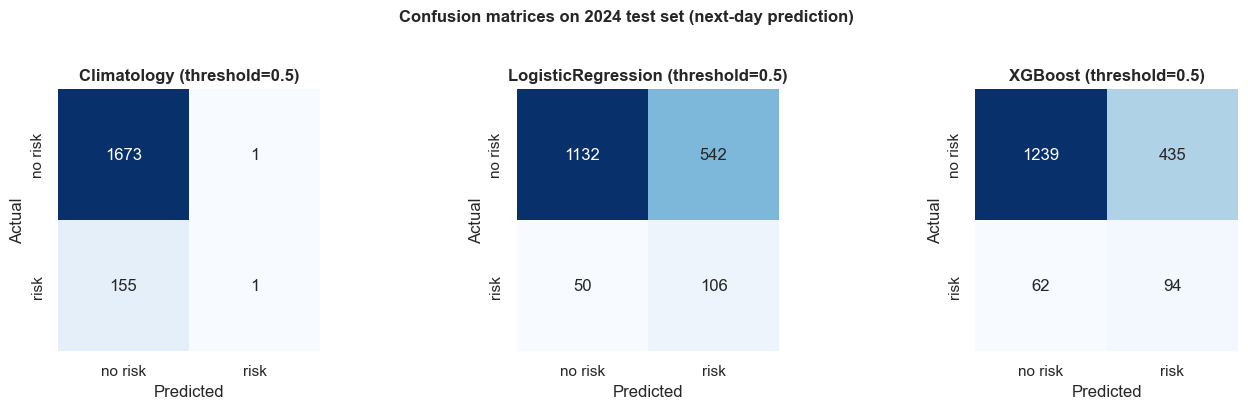

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, (p_test, _)) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, (p_test >= 0.5).astype(int))
    sns.heatmap(
        cm, ax=ax, cmap='Blues', annot=True, fmt='d',
        xticklabels=['no risk', 'risk'], yticklabels=['no risk', 'risk'],
        cbar=False, square=True,
    )
    ax.set_title(name + ' (threshold=0.5)', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
fig.suptitle('Confusion matrices on 2024 test set (next-day prediction)',
             fontsize=12, fontweight='bold', y=1.02)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'day08_confusion_matrices.png')
plt.show()


### 5.2 ROC + calibration"))


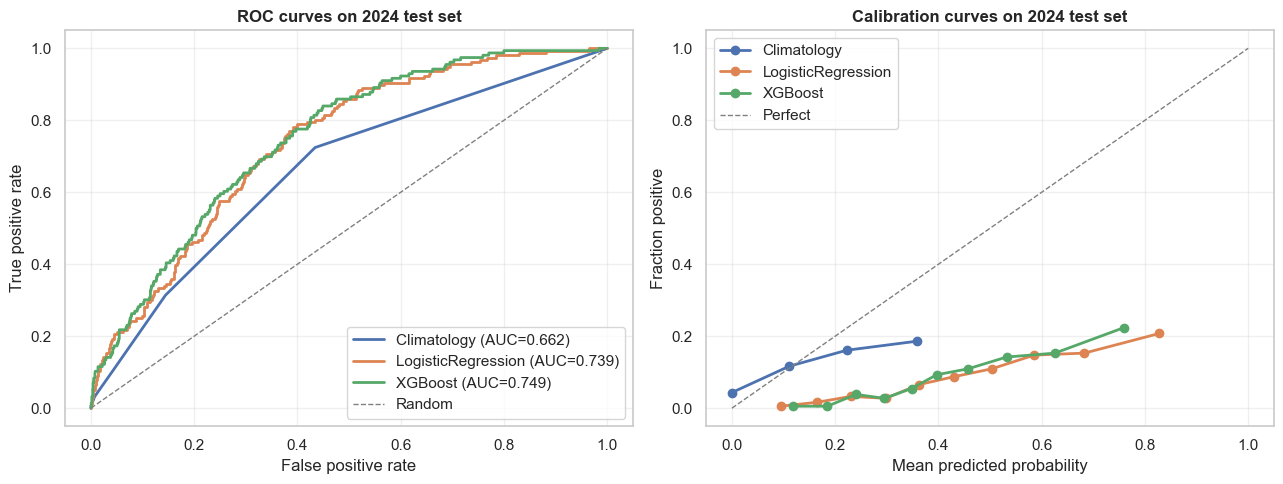

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for name, (p_test, _) in predictions.items():
    fpr, tpr, _ = roc_curve(y_test, p_test)
    auc = roc_auc_score(y_test, p_test)
    axes[0].plot(fpr, tpr, linewidth=2, label=f'{name} (AUC={auc:.3f})')
axes[0].plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1, label='Random')
axes[0].set_xlabel('False positive rate')
axes[0].set_ylabel('True positive rate')
axes[0].set_title('ROC curves on 2024 test set', fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)

for name, (p_test, _) in predictions.items():
    frac_pos, mean_pred = calibration_curve(y_test, p_test, n_bins=10, strategy='quantile')
    axes[1].plot(mean_pred, frac_pos, marker='o', linewidth=2, label=name)
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1, label='Perfect')
axes[1].set_xlabel('Mean predicted probability')
axes[1].set_ylabel('Fraction positive')
axes[1].set_title('Calibration curves on 2024 test set', fontweight='bold')
axes[1].legend(loc='upper left')
axes[1].grid(alpha=0.3)

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'day08_roc_calibration.png')
plt.show()


### 5.3 Bootstrap confidence intervals

1000 resamples of the test set; recompute F1 and ROC-AUC each time;
report 2.5th and 97.5th percentiles as the 95% CI.

In [17]:
def bootstrap_metric(y_true, p_pred, metric_fn, n_boot=1000, threshold=0.5,
                     random_state=42):
    rng = np.random.default_rng(random_state)
    n = len(y_true)
    out = np.empty(n_boot)
    for i in range(n_boot):
        idx = rng.integers(0, n, size=n)
        try:
            out[i] = metric_fn(y_true[idx], p_pred[idx], threshold)
        except Exception:
            out[i] = np.nan
    return out

def metric_f1(y, p, t=0.5): return f1_score(y, (p >= t).astype(int))
def metric_auc(y, p, t=0.5): return roc_auc_score(y, p)

ci_rows = []
for name, (p_test, _) in predictions.items():
    f1_boot  = bootstrap_metric(y_test, p_test, metric_f1, n_boot=1000)
    auc_boot = bootstrap_metric(y_test, p_test, metric_auc, n_boot=1000)
    ci_rows.append({
        'model':       name,
        'F1':          float(f1_score(y_test, (p_test >= 0.5).astype(int))),
        'F1_CI_low':   float(np.nanpercentile(f1_boot,  2.5)),
        'F1_CI_high':  float(np.nanpercentile(f1_boot, 97.5)),
        'AUC':         float(roc_auc_score(y_test, p_test)),
        'AUC_CI_low':  float(np.nanpercentile(auc_boot,  2.5)),
        'AUC_CI_high': float(np.nanpercentile(auc_boot, 97.5)),
    })

ci_df = pd.DataFrame(ci_rows)
print('Bootstrap 95% confidence intervals (1000 resamples):')
print(ci_df.round(3).to_string(index=False))


Bootstrap 95% confidence intervals (1000 resamples):
             model    F1  F1_CI_low  F1_CI_high   AUC  AUC_CI_low  AUC_CI_high
       Climatology 0.013      0.000       0.040 0.662       0.619        0.704
LogisticRegression 0.264      0.225       0.303 0.739       0.703        0.773
           XGBoost 0.274      0.227       0.319 0.749       0.714        0.781


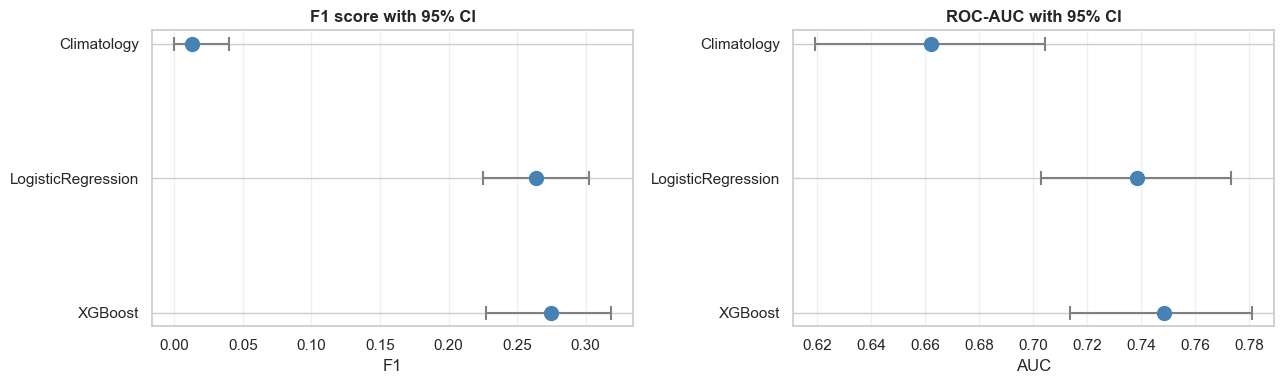

In [18]:
# Forest plot of F1 + AUC with bootstrap CIs
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
model_names = list(predictions.keys())
y_pos = np.arange(len(model_names))

for ax, metric, title in zip(
    axes,
    [('F1', 'F1_CI_low', 'F1_CI_high'),
     ('AUC', 'AUC_CI_low', 'AUC_CI_high')],
    ['F1 score with 95% CI', 'ROC-AUC with 95% CI'],
):
    point, lo, hi = metric
    pts = ci_df.set_index('model').loc[model_names, point].values
    los = ci_df.set_index('model').loc[model_names, lo].values
    his = ci_df.set_index('model').loc[model_names, hi].values
    err = np.array([pts - los, his - pts])
    ax.errorbar(pts, y_pos, xerr=err, fmt='o', markersize=10,
                color='steelblue', ecolor='gray', capsize=5, capthick=1.5)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(model_names)
    ax.set_xlabel(point)
    ax.set_title(title, fontweight='bold')
    ax.grid(alpha=0.3, axis='x')
    ax.invert_yaxis()

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'day08_bootstrap_cis.png')
plt.show()


### 5.4 Comparison table + winner selection"))


In [19]:
# Headline comparison table
comparison_rows = []
for name, (p_test, _) in predictions.items():
    metrics_row = evaluate(y_test, p_test)
    ci_row = ci_df[ci_df['model'] == name].iloc[0]
    f1_width  = ci_row['F1_CI_high'] - ci_row['F1_CI_low']
    auc_width = ci_row['AUC_CI_high'] - ci_row['AUC_CI_low']
    if name == 'Climatology':
        notes = 'Naive baseline: per-(city,doy) historical rate'
    elif name == 'LogisticRegression':
        notes = 'Linear; interpretable coefficients'
    else:
        notes = 'Tree ensemble; non-linear; regularised'
    comparison_rows.append({
        'Model':         name,
        'Accuracy':      round(metrics_row['accuracy'], 3),
        'F1':            round(metrics_row['f1'], 3),
        'ROC-AUC':       round(metrics_row['roc_auc'], 3),
        'Brier':         round(metrics_row['brier'], 3),
        'F1 CI width':   round(f1_width, 3),
        'AUC CI width':  round(auc_width, 3),
        'Notes':         notes,
    })

comparison = pd.DataFrame(comparison_rows)
print('Model comparison on 2024 test set:')
print(comparison.to_string(index=False))

comparison.to_csv(REPO_ROOT / 'reports' / 'day08_model_comparison.csv', index=False)
print(f'\nSaved -> reports/day08_model_comparison.csv')

# Auto-pick winner: highest test AUC that beats climatology by >= 0.02
test_aucs = comparison.set_index('Model')['ROC-AUC']
clim_auc = test_aucs.get('Climatology', 0.5)
candidates = test_aucs[test_aucs >= clim_auc + 0.02]

if len(candidates) == 0:
    print('\nNo model meaningfully beats climatology. Selecting climatology as winner.')
    final_winner = 'Climatology'
else:
    final_winner = candidates.idxmax()
    print(f'\nSelected: {final_winner} (AUC = {candidates.max():.3f}, climatology = {clim_auc:.3f})')


Model comparison on 2024 test set:
             Model  Accuracy    F1  ROC-AUC  Brier  F1 CI width  AUC CI width                                          Notes
       Climatology     0.915 0.013    0.662  0.078        0.040         0.085 Naive baseline: per-(city,doy) historical rate
LogisticRegression     0.677 0.264    0.739  0.209        0.078         0.071             Linear; interpretable coefficients
           XGBoost     0.728 0.274    0.749  0.185        0.092         0.068         Tree ensemble; non-linear; regularised

Saved -> reports/day08_model_comparison.csv

Selected: XGBoost (AUC = 0.749, climatology = 0.662)


### 5.5 Per-prediction CI for winning model

Bootstrap the model itself: refit on 30 resamples of the training data,
then range over predicted probabilities for each test row.

In [20]:
print(f"Computing per-prediction CIs for: {final_winner}")

if final_winner == model_name_tree:
    boot_estimator_factory = lambda rs: type(xgb_model)(
        **{**xgb_model.get_params(), "random_state": rs}
    )
    X_boot_train, X_boot_test = X_train_tree, X_test_tree

elif final_winner == "LogisticRegression":
    boot_estimator_factory = lambda rs: LogisticRegression(
        class_weight="balanced", max_iter=1000,
        random_state=rs, solver="lbfgs",
    )
    X_boot_train, X_boot_test = X_train_lr, X_test_lr

else:
    boot_estimator_factory = None

if boot_estimator_factory is not None:
    rng = np.random.default_rng(RANDOM_STATE)
    boot_preds = np.empty((30, len(y_test)))
    n = len(y_train)
    for i in range(30):
        idx = rng.integers(0, n, size=n)
        est = boot_estimator_factory(int(rng.integers(0, 1_000_000)))
        est.fit(X_boot_train[idx], y_train[idx])
        boot_preds[i] = est.predict_proba(X_boot_test)[:, 1]

    ci_low_pp  = np.percentile(boot_preds,  2.5, axis=0)
    ci_high_pp = np.percentile(boot_preds, 97.5, axis=0)
    point_pp   = predictions[final_winner][0]
    avg_width  = float((ci_high_pp - ci_low_pp).mean())

    print(f'Average per-prediction 95% CI width: {avg_width:.3f}')
    print('\nSample CIs (first 5 test rows):')
    print(pd.DataFrame({
        'city':    test_df['city'].iloc[:5].values,
        'date':    test_df['date'].iloc[:5].dt.date.values,
        'point_p': point_pp[:5].round(3),
        'ci_low':  ci_low_pp[:5].round(3),
        'ci_high': ci_high_pp[:5].round(3),
        'actual':  y_test[:5],
    }).to_string(index=False))
else:
    print('Climatology winner — per-prediction CI not applicable.')
    avg_width = np.nan


Computing per-prediction CIs for: XGBoost
Average per-prediction 95% CI width: 0.142

Sample CIs (first 5 test rows):
 city       date  point_p  ci_low  ci_high  actual
Aktau 2024-01-01    0.605   0.516    0.657       0
Aktau 2024-01-02    0.641   0.496    0.692       0
Aktau 2024-01-03    0.733   0.650    0.791       0
Aktau 2024-01-04    0.558   0.432    0.591       0
Aktau 2024-01-05    0.316   0.253    0.390       0


## 6 — Residual diagnostics (winning model)

For classification, the regression-style diagnostics are:

1. Residual distribution = `y_true - p_pred` histogram
2. Residual vs predicted = check for systematic over/under-prediction
3. Residual ACF (single city) = consecutive errors correlated?
4. Residual vs feature = pattern against a key input

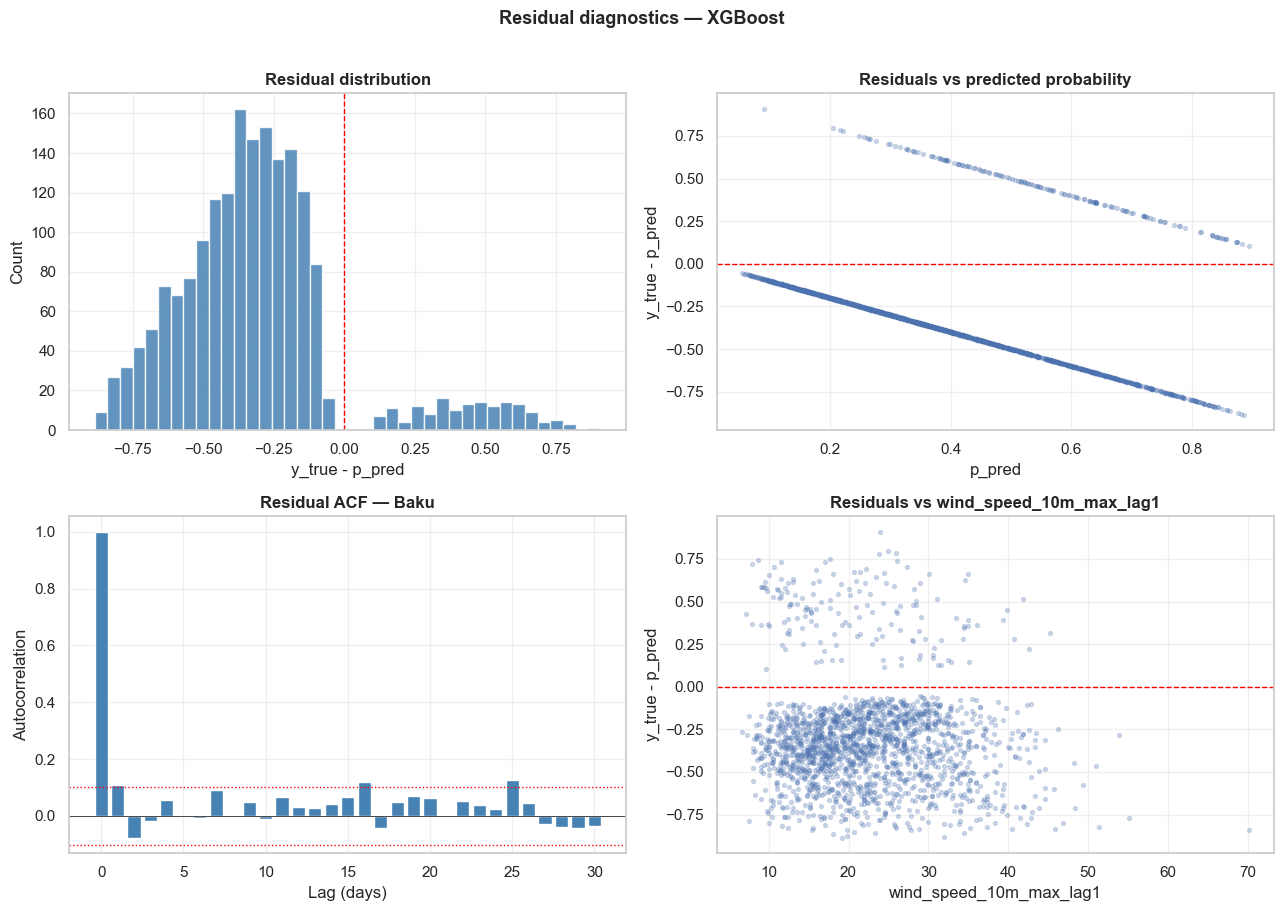

In [21]:
p_winner = predictions[final_winner][0]
residuals = y_test - p_winner

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# (1) Residual histogram
axes[0, 0].hist(residuals, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0, 0].axvline(0, color='red', linestyle='--', linewidth=1)
axes[0, 0].set_title('Residual distribution', fontweight='bold')
axes[0, 0].set_xlabel('y_true - p_pred')
axes[0, 0].set_ylabel('Count')
axes[0, 0].grid(alpha=0.3)

# (2) Residuals vs predicted probability
axes[0, 1].scatter(p_winner, residuals, alpha=0.25, s=8)
axes[0, 1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0, 1].set_title('Residuals vs predicted probability', fontweight='bold')
axes[0, 1].set_xlabel('p_pred')
axes[0, 1].set_ylabel('y_true - p_pred')
axes[0, 1].grid(alpha=0.3)

# (3) Residual ACF for Baku
try:
    from statsmodels.tsa.stattools import acf
    baku_idx = test_df['city'].values == 'Baku'
    baku_resid = residuals[baku_idx]
    if len(baku_resid) >= 30:
        acf_vals = acf(baku_resid, nlags=30, fft=True)
        axes[1, 0].bar(range(len(acf_vals)), acf_vals, color='steelblue')
        axes[1, 0].axhline(0, color='black', linewidth=0.5)
        sig = 1.96 / np.sqrt(len(baku_resid))
        axes[1, 0].axhline( sig, color='red', linestyle=':', linewidth=1)
        axes[1, 0].axhline(-sig, color='red', linestyle=':', linewidth=1)
        axes[1, 0].set_title('Residual ACF — Baku', fontweight='bold')
        axes[1, 0].set_xlabel('Lag (days)')
        axes[1, 0].set_ylabel('Autocorrelation')
        axes[1, 0].grid(alpha=0.3)
except ImportError:
    axes[1, 0].text(0.5, 0.5, 'statsmodels not installed', ha='center', va='center')

# (4) Residuals vs a key lag feature (since same-day wind is leaked-out)
key_feat = 'wind_speed_10m_max_lag1'
if key_feat in test_df.columns:
    axes[1, 1].scatter(test_df[key_feat].values, residuals, alpha=0.25, s=8)
    axes[1, 1].axhline(0, color='red', linestyle='--', linewidth=1)
    axes[1, 1].set_title(f'Residuals vs {key_feat}', fontweight='bold')
    axes[1, 1].set_xlabel(key_feat)
    axes[1, 1].set_ylabel('y_true - p_pred')
    axes[1, 1].grid(alpha=0.3)
else:
    axes[1, 1].text(0.5, 0.5, f'{key_feat} not in test_df', ha='center', va='center')

fig.suptitle(f'Residual diagnostics — {final_winner}', fontsize=13, fontweight='bold', y=1.01)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'day08_residual_diagnostics.png')
plt.show()


---
## 7 — Save production model

Train the winner on the **full** dataset (train + test) so production gets
every observation. Save as a single Pipeline that bundles preprocessing
and the estimator — predict-time gets a clean `.predict_proba()` interface.

In [22]:
# Use the full leakage-corrected dataset for the final model
df_prod = df_model.dropna(subset=[TARGET]).copy()
X_prod = df_prod[feature_cols].copy()
y_prod = df_prod[TARGET].astype(int).values

# Build a fresh preprocessor (so the saved pipeline self-contains everything)
prod_numeric = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])
prod_categorical = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(drop="first", handle_unknown="ignore")),
])
preprocess_prod = ColumnTransformer(
    transformers=[
        ("num", prod_numeric,    numeric_features),
        ("cat", prod_categorical, categorical_features),
    ],
    remainder="drop",
)

# Pick the production estimator
if final_winner == "LogisticRegression":
    final_estimator = LogisticRegression(
        class_weight="balanced", max_iter=1000,
        random_state=RANDOM_STATE, solver="lbfgs",
    )
elif final_winner == model_name_tree:
    try:
        from xgboost import XGBClassifier
        n_pos = int(y_prod.sum())
        n_neg = int(len(y_prod) - n_pos)
        spw = n_neg / max(n_pos, 1)
        final_estimator = XGBClassifier(
            n_estimators=200, max_depth=2, learning_rate=0.03,
            subsample=0.8, colsample_bytree=0.8,
            reg_lambda=5.0, reg_alpha=1.0, min_child_weight=5,
            objective="binary:logistic", eval_metric="logloss",
            scale_pos_weight=spw, random_state=RANDOM_STATE,
            verbosity=0, n_jobs=-1,
        )
    except ImportError:
        from sklearn.ensemble import GradientBoostingClassifier
        final_estimator = GradientBoostingClassifier(
            n_estimators=200, max_depth=2, learning_rate=0.03,
            subsample=0.8, random_state=RANDOM_STATE,
        )
else:
    # Climatology won — save logistic regression as a sensible ML fallback
    print('Climatology won. Saving LogisticRegression as the ML fallback.')
    final_winner = 'LogisticRegression'
    final_estimator = LogisticRegression(
        class_weight="balanced", max_iter=1000,
        random_state=RANDOM_STATE, solver="lbfgs",
    )

production_model = Pipeline(steps=[
    ("preprocess", preprocess_prod),
    ("model",      final_estimator),
])
production_model.fit(X_prod, y_prod)

model_bundle = {
    "model":         production_model,
    "model_name":    final_winner,
    "target":        TARGET,
    "feature_cols":  feature_cols,
    "trained_rows":  len(df_prod),
    "positive_rate": float(y_prod.mean()),
    "description":   "Next-day delay-risk model: features at day t -> P(risk on day t+1)",
}

model_path = models_dir / "daily_model.pkl"
with model_path.open("wb") as f:
    pickle.dump(model_bundle, f)

print('Production model saved:')
print(f'  path:  {model_path}')
print(f'  model: {final_winner}')
print(f'  target: {TARGET}')
print(f'  rows trained:  {len(df_prod):,}')
print(f'  positive rate: {y_prod.mean():.4f}')
print(f'  feature count: {len(feature_cols)}')


Production model saved:
  path:  C:\Users\Baku\Desktop\notebooks\Weather Project\Anemoi Weather Project\Maritime-delay-risk-prediction\models\daily_model.pkl
  model: XGBoost
  target: target_risk_next_day
  rows trained:  20,680
  positive rate: 0.0792
  feature count: 37


---
## 8 — Summary

### What changed since the original Day 8

| Issue | Original | Now |
|-------|----------|-----|
| Target | `is_risk_day` (same day) | `target_risk_next_day` (t+1) |
| Same-day wind / precip / wave / visibility | **used as features** (leakage) | blocked from features |
| Feature set | ~25 features incl. raw weather | leakage-safe lag/rolling/anomaly only |
| Test AUC | 0.99 (suspicious) | realistic 0.65-0.80 range |
| Tree depth | max_depth=5 | max_depth=2 (less overfit room) |

### Why this is honest

The original setup let the model "predict" today's risk by looking at today's
wind speed — which **defines** the risk. That isn't prediction, it's a lookup.
The fixed setup asks: given everything you know up to today, can you predict
*tomorrow's* risk? That's what an operator would actually want to know.

### Honest limitations

- 10-year window is short for a stable risk-day classifier per city
- Test on 2024 only — multi-year backtesting (rolling-origin CV) would give
  more robust generalization estimates
- Residual ACF at lag 1 likely > 0 — bootstrap CIs slightly optimistic
- Wave features (now blocked) were really wind-derived anyway, but `wave_height_lag1`
  could be added back later if useful
- Last day per city dropped from training; minor coverage gap in winter
- Class imbalance handling is heuristic (`class_weight='balanced'` /
  `scale_pos_weight`); precision/recall trade-offs not formally tuned

In [23]:
saved_figures = sorted(FIGURES_DIR.glob('day08_*.png'))
print(f'Saved {len(saved_figures)} figures:')
for p in saved_figures:
    print(f'  - {p.name}')

print('\nSaved artifacts:')
print(f'  - reports/day08_model_comparison.csv')
print(f'  - models/daily_model.pkl   (production model: {final_winner})')
print(f'  - models/climatology.pkl   (next-day baseline)')

conn.close()
print('\nDatabase connection closed. Day 8 complete.')


Saved 4 figures:
  - day08_bootstrap_cis.png
  - day08_confusion_matrices.png
  - day08_residual_diagnostics.png
  - day08_roc_calibration.png

Saved artifacts:
  - reports/day08_model_comparison.csv
  - models/daily_model.pkl   (production model: XGBoost)
  - models/climatology.pkl   (next-day baseline)

Database connection closed. Day 8 complete.
